# 02. Hfq 依存 sRNA による標的 mRNA 抑制の最小回路

細菌では、小分子 RNA（sRNA）が RNA シャペロン **Hfq** を介して標的 mRNA と塩基対合し、
両者が **共分解（co-degradation）** で一緒に消える——これが転写後制御の要。
この分子（Hfq / sRNA）の **進化・系統** を扱うのが `bio-a_hfq-phylogenetics` なら、
本ノートはその **相棒**: 進化が保存してきた制御回路が「動力学としてどう振る舞うか」を数式で回す。

## 最小モデル（5 反応）

| 反応 | 速度 | 意味 |
|---|---|---|
| $\varnothing \to m$ | $a_m$ | mRNA 転写 |
| $\varnothing \to s$ | $a_s$ | sRNA 転写（← 制御ノブ） |
| $m \to \varnothing$ | $b_m$ | mRNA 分解 |
| $s \to \varnothing$ | $b_s$ | sRNA 分解 |
| $m + s \to \varnothing$ | $k$ | Hfq 依存ペアリングによる共分解 |

**予想**: $a_s$ が $a_m$ を超えると mRNA が閾値的に急落する（Levine et al. 2007 の *threshold-linear* 応答）。
さらに確率シミュレーションでは、その閾値近傍で mRNA の **ゆらぎが増幅**される。

## モデルを明示的に組む

01 の `reaction_rules()` DSL は **グローバルなモデルに反応を累積**するため、
パラメータ（ここでは $a_s$）を変えて何度も作り直す掃引には不向き。
そこで `ecell4_base.core` の `ReactionRule([反応物],[生成物],k)` で
**毎回まっさらな `NetworkModel`** を組む。合成は反応物なし `[]`、分解は生成物なし `[]`。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

M, S = Species('m'), Species('s')
A_M, B_M, B_S, K = 10.0, 1.0, 1.0, 100.0   # 転写 / mRNA分解 / sRNA分解 / ペアリング

def build_model(a_s):
    mdl = NetworkModel()
    for rr in [ReactionRule([], [M], A_M),   # ∅ -> m
               ReactionRule([], [S], a_s),   # ∅ -> s
               ReactionRule([M], [], B_M),   # m -> ∅
               ReactionRule([S], [], B_S),   # s -> ∅
               ReactionRule([M, S], [], K)]: # m + s -> ∅
        mdl.add_reaction_rule(rr)
    return mdl

## 確率的な時系列を 3 つのレジームで眺める

閾値の下（$a_s{=}4$）・ちょうど（$a_s{=}10$）・上（$a_s{=}16$）で mRNA 分子数 $m(t)$ を Gillespie で走らせる。
閾値付近で振れ幅が大きくなるのが目で見える。

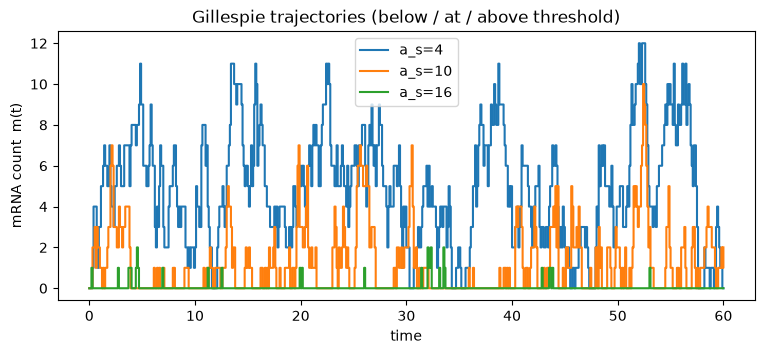

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for a_s, c in [(4, 'C0'), (10, 'C1'), (16, 'C2')]:
    ret = run_simulation(60.0, y0={'m':0,'s':0}, model=build_model(float(a_s)),
                         solver='gillespie', ndiv=600, species_list=['m','s'], rndseed=1)
    arr = ret.as_array()
    ax.step(arr[:,0], arr[:,1], where='post', color=c, label=f'a_s={a_s}')
ax.set_xlabel('time'); ax.set_ylabel('mRNA count  m(t)')
ax.set_title('Gillespie trajectories (below / at / above threshold)'); ax.legend()
plt.show()

## $a_s$ を掃引して応答曲線とノイズを測る

In [3]:
def ode_steady(a_s):
    ret = run_simulation(80.0, y0={'m':0,'s':0}, model=build_model(a_s),
                         solver='ode', ndiv=800, species_list=['m','s'])
    return ret.as_array()[-1][1]

def gillespie_stats(a_s, t_end=400.0, ndiv=4000, burn=0.25, seed=0):
    ret = run_simulation(t_end, y0={'m':0,'s':0}, model=build_model(a_s),
                         solver='gillespie', ndiv=ndiv, species_list=['m','s'], rndseed=seed)
    tail = ret.as_array()[int(ndiv*burn):, 1]
    return tail.mean(), tail.std()

a_s_grid = np.array([0,2,4,6,8,9,10,11,12,14,16,20], dtype=float)
ode = np.array([ode_steady(a) for a in a_s_grid])
g_mean, g_std = np.array([gillespie_stats(a) for a in a_s_grid]).T

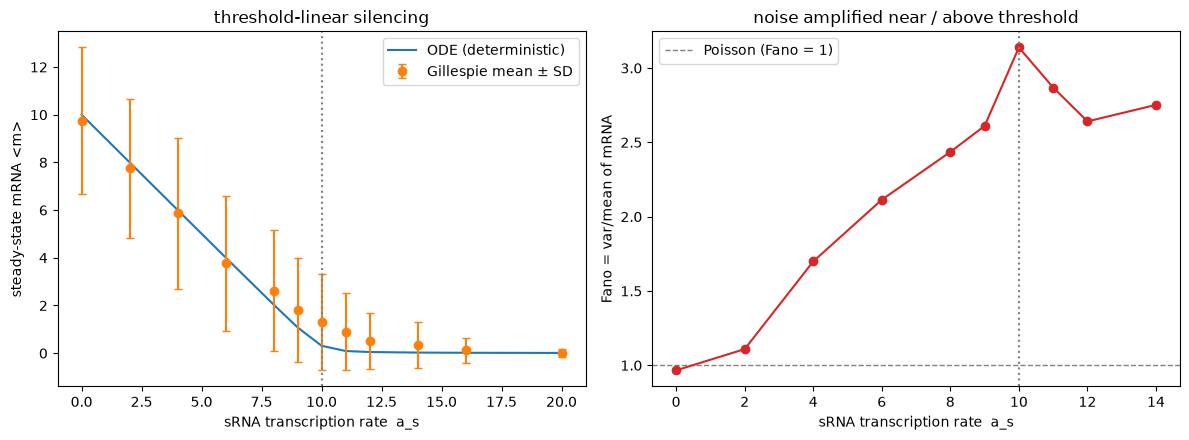

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(a_s_grid, ode, '-', color='C0', label='ODE (deterministic)')
ax1.errorbar(a_s_grid, g_mean, yerr=g_std, fmt='o', color='C1', capsize=3,
             label='Gillespie mean ± SD')
ax1.axvline(A_M, ls=':', c='gray'); ax1.set_title('threshold-linear silencing')
ax1.set_xlabel('sRNA transcription rate  a_s'); ax1.set_ylabel('steady-state mRNA <m>'); ax1.legend()

fano = np.where(g_mean > 0.3, g_std**2 / np.where(g_mean > 0, g_mean, 1), np.nan)
ax2.axhline(1.0, ls='--', c='gray', lw=1, label='Poisson (Fano = 1)')
ax2.plot(a_s_grid, fano, 'o-', color='C3'); ax2.axvline(A_M, ls=':', c='gray')
ax2.set_xlabel('sRNA transcription rate  a_s'); ax2.set_ylabel('Fano = var/mean of mRNA')
ax2.set_title('noise amplified near / above threshold'); ax2.legend()
plt.tight_layout(); plt.show()

## 読み取り

- **左**: $a_s < a_m$ では $\langle m\rangle \approx (a_m - a_s)/b_m$ と線形に減り、$a_s = a_m$ を境に急落。sRNA は「化学量論的（stoichiometric）」なスイッチとして働く。
- **右**: Fano factor が閾値付近で 1（Poisson）から $\sim 3$ へ増幅。**sRNA 制御は閾値近くで最もノイジー**。

## 発展課題（自作）（研究に寄せる）

1. ペアリング速度 $k$ を下げる（例 $100\to 5$）と、閾値の鋭さはどうなる？ Hfq の結合親和性の違いに対応づけて考える。
2. mRNA からタンパク質翻訳 $m \to m + P$ を足し、$P$ の出力ノイズを見る（制御の下流はもっと平滑化される？）。
3. sRNA を「触媒的」に変える（$m + s \to s$: sRNA は再利用される）と、threshold-linear が Michaelis-Menten 的な応答に変わることを確認する。
4. `bio-a` で見た Hfq のオーソログ間で結合様式が違うなら、それを $k$ や $b_s$ の違いとしてこのモデルに反映し、制御レジームの差を議論する。